In [ ]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
# Walks up from the notebook's working directory until it finds pyproject.toml,
# then adds that directory to sys.path so `from twopoint_lockin import ...` etc. work
# regardless of which subfolder the notebook lives in. PROJECT_ROOT is also exposed
# so cells below can build absolute paths to data/ and qick-dawg-patch/.
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Unit / scaling defaults (safe defaults if not set elsewhere)
DATA_IN_MICROVOLTS = True  # raw data in file is in microvolts
CONVERT_TO_VOLTS = True
MICROVOLT_TO_VOLT = 1e-6
UNIT_SCALE = MICROVOLT_TO_VOLT if (DATA_IN_MICROVOLTS and CONVERT_TO_VOLTS) else 1.0
UNIT_PLOT = 'V' if CONVERT_TO_VOLTS else ('μV' if DATA_IN_MICROVOLTS else 'V')
# filename should be set by user; keep a placeholder if missing
# filename = 'path/to/your/file.csv'


Text(0.5, 1.0, 'ESR Spectrum')

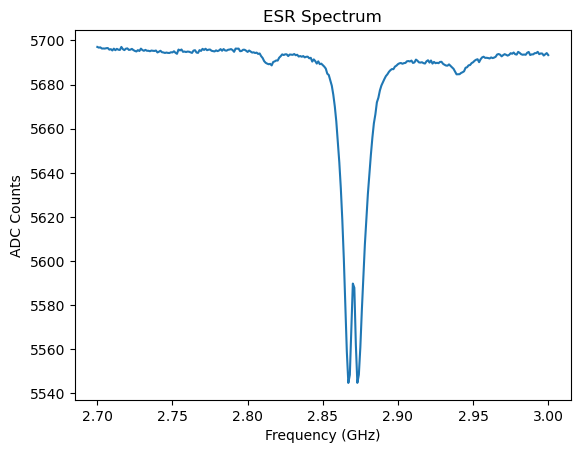

In [9]:
# Set the filename to a .csv or the original text format
filename = '/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/odmr_sweep_20260323_162035.csv'

if filename.lower().endswith('.csv'):
    # Read CSV using pandas; expect at least two columns (frequency, counts)
    df = pd.read_csv(filename)
    if df.shape[1] < 2:
        raise ValueError(f'CSV {filename} must have at least two columns (frequency, counts)')
    data = df.iloc[:, :4].to_numpy(dtype=float)
else:
    rows = []
    with open(filename, 'r') as f:
        for line in f:
            line_strip = line.strip()
            if line_strip == 'END':
                break
            if not line_strip:
                continue
            parts = line_strip.split()
            try:
                x = float(parts[0])
                y = float(parts[1])
                rows.append((x, y))
            except Exception:
                continue
    if len(rows) == 0:
        raise ValueError(f'No numeric data found in {filename} before END')
    data = np.array(rows)

# Data file is in MHz; convert to GHz for plotting and fitting
Frequency = data[:, 0] / 1e3
counts = data[:, 1]
counts = counts +5750

# Plot the data
plt.plot(Frequency, counts)
plt.xlabel('Frequency (GHz)')
plt.ylabel('ADC Counts')
plt.title('ESR Spectrum')


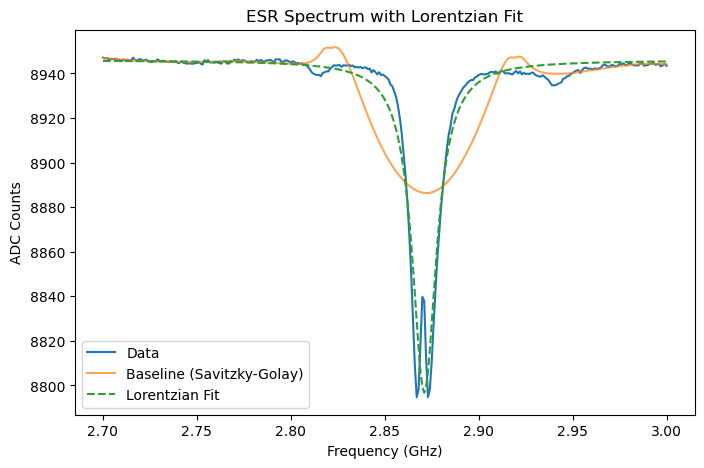

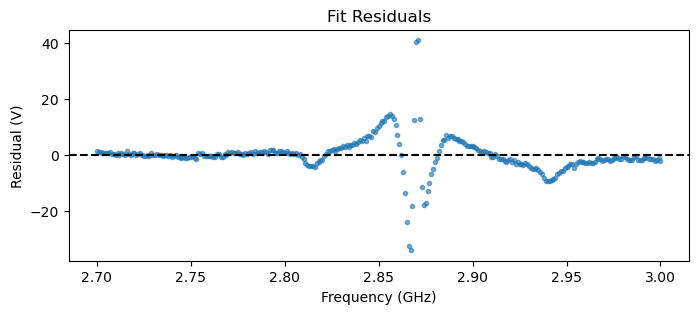

Fitted parameters:
x0 (center, GHz): 2.8710201306663095
gamma (width, GHz): 0.007693294222117906
a (amplitude): -149.15694735446917
d (offset): 8945.90191242267


In [3]:
from scipy.optimize import curve_fit

from scipy.signal import savgol_filter


def lorentzian(x, x0, gamma, a, d):
    return a * gamma**2 / ((x - x0)**2 + gamma**2) + d


# Prepare data: sort by frequency and compute a smooth baseline
sort_idx = np.argsort(Frequency)
xf = Frequency[sort_idx]
yf = counts[sort_idx]

# Remove NaNs/Infs if present
valid = np.isfinite(xf) & np.isfinite(yf)
xf = xf[valid]
yf = yf[valid]

n = len(yf)
if n == 0:
    raise ValueError('No valid data to fit')

# choose an odd window length <= n for Savitzky-Golay
win = min(101, n if n%2==1 else n-1)
if win < 5:
    win = 5
baseline = savgol_filter(yf, window_length=win, polyorder=3)

# detrend and locate candidate peak
yf_detrended = yf - baseline
# use absolute to find largest feature (peak or dip)
peak_idx = int(np.argmax(np.abs(yf_detrended)))

# Initial guesses (note: Frequency is in GHz)
x0_guess = float(xf[peak_idx])
# estimate amplitude preserving sign
a_guess = float(yf_detrended[peak_idx])

# Estimate gamma (width) from points around half-maximum if possible
gamma_guess = (xf.max() - xf.min()) / 50.0
try:
    half = 0.5 * np.abs(a_guess)
    mask_half = np.abs(yf_detrended) >= half
    if mask_half.sum() >= 2:
        xf_half = xf[mask_half]
        gamma_guess = max((xf_half.max() - xf_half.min()) / 2.0, gamma_guess)
except Exception:
    pass

# If the initial amplitude guess is extremely small, fallback to data span
if np.isclose(a_guess, 0):
    a_guess = float(np.max(yf_detrended) - np.min(yf_detrended))

# offset guess from baseline median
d_guess = float(np.median(baseline))
initial_guess = [x0_guess, gamma_guess, a_guess, d_guess]

# Bounds to keep fit physical (gamma>0)
range_x = xf.max() - xf.min()
lower_bounds = [xf.min(), 1e-12, -np.inf, -np.inf]
upper_bounds = [xf.max(), max(range_x, 1e-6), np.inf, np.inf]

# Try curve_fit with reasonable maxfev; if it fails, try an alternative strategy
try:
    popt, pcov = curve_fit(lorentzian, xf, yf, p0=initial_guess, bounds=(lower_bounds, upper_bounds), maxfev=200000)
except Exception as e:
    # Try a relaxed guess and less strict bounds
    try:
        initial_guess[1] = max(gamma_guess, range_x / 20.0)
        popt, pcov = curve_fit(lorentzian, xf, yf, p0=initial_guess, maxfev=200000)
    except Exception as e2:
        raise RuntimeError('Lorentzian fit failed; try inspecting initial guesses or data')

fit_y = lorentzian(xf, *popt)

plt.figure(figsize=(8,5))
plt.plot(xf, yf, label='Data')
plt.plot(xf, baseline, label='Baseline (Savitzky-Golay)', alpha=0.7)
plt.plot(xf, fit_y, '--', label='Lorentzian Fit')
plt.xlabel('Frequency (GHz)')
plt.ylabel('ADC Counts')
plt.title('ESR Spectrum with Lorentzian Fit')
plt.legend()
plt.show()

# Plot residuals to inspect fit quality
plt.figure(figsize=(8,3))
plt.plot(xf, yf - fit_y, '.', alpha=0.6)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Residual (V)')
plt.title('Fit Residuals')
plt.show()

print('Fitted parameters:')
print(f"x0 (center, GHz): {popt[0]}")
print(f"gamma (width, GHz): {popt[1]}")
print(f"a (amplitude): {popt[2]}")
print(f"d (offset): {popt[3]}")


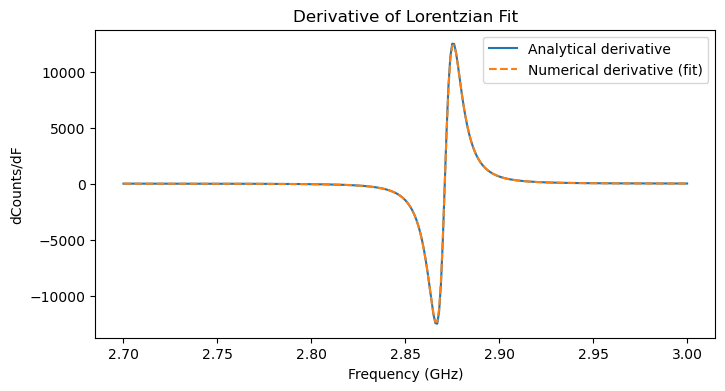

In [4]:
# Analytical derivative of the fitted Lorentzian
def lorentzian_derivative(x, x0, gamma, a):
    denom = (x - x0)**2 + gamma**2
    return -2 * a * gamma**2 * (x - x0) / denom**2

# Unpack fitted parameters from previous fit
x0_fit, gamma_fit, a_fit, d_fit = popt

# Compute analytical derivative of the fit and compare to numerical derivative
deriv_fit = lorentzian_derivative(xf, x0_fit, gamma_fit, a_fit)
deriv_fit_num = np.gradient(fit_y, xf)

plt.figure(figsize=(8,4))
plt.plot(xf, deriv_fit, label='Analytical derivative')
plt.plot(xf, deriv_fit_num, '--', label='Numerical derivative (fit)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('dCounts/dF')
plt.title('Derivative of Lorentzian Fit')
plt.legend()
plt.show()

Number of points: 101
Standard deviation (population): 6.628980e-01
Standard deviation (sample, ddof=1): 6.662043e-01


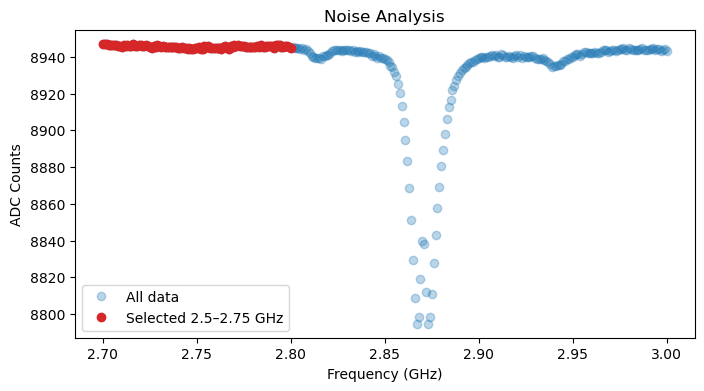

In [5]:
# Compute standard deviation of counts between 2.5 GHz and 2.75 GHz
#mask = (Frequency >= 3.25) & (Frequency <= 3.5)
mask = (Frequency >= 2.70) & (Frequency <= 2.8)
freq_sel = Frequency[mask]
counts_sel = counts[mask]
if counts_sel.size == 0:
    print('No data points found in 2.5–2.75 GHz range')
else:
    std_pop = np.std(counts_sel)
    std_samp = np.std(counts_sel, ddof=1) if counts_sel.size > 1 else float('nan')
    print(f'Number of points: {counts_sel.size}')
    print(f'Standard deviation (population): {std_pop:e}')
    print(f'Standard deviation (sample, ddof=1): {std_samp:e}')
    plt.figure(figsize=(8,4))
    plt.plot(Frequency, counts, marker='o', linestyle='none', alpha=0.3, label='All data')
    plt.plot(freq_sel, counts_sel, 'o', color='C3', label='Selected 2.5–2.75 GHz')
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('ADC Counts')
    plt.title('Noise Analysis')
    plt.legend()
    plt.show()

In [6]:
I_time = 213e-6  # time per point in seconds
noise_density = std_samp * np.sqrt(I_time)  # Counts/√Hz
print(f'Noise density: {noise_density} Counts/√Hz')

gyromagnetic_ratio = 28  # GHz/T
Response_slope = np.max(np.abs(deriv_fit))  # Counts/GHz
print(f'Maximum response slope: {Response_slope} Counts/GHz')

response = gyromagnetic_ratio * Response_slope  # Counts/T
print(f'Response: {response} Counts/T')

sensitivity = noise_density / response  # T/√Hz
print(f'Sensitivity: {sensitivity} T/√Hz')

Noise density: 0.009722931181305945 Counts/√Hz
Maximum response slope: 12502.395771589341 Counts/GHz
Response: 350067.0816045016 Counts/T
Sensitivity: 2.777448007033894e-08 T/√Hz


File not found: ESR_2026-1-9_011.txt
File not found: ESR_2026-1-13_002.txt
File not found: ESR_2025-11-10_004.txt


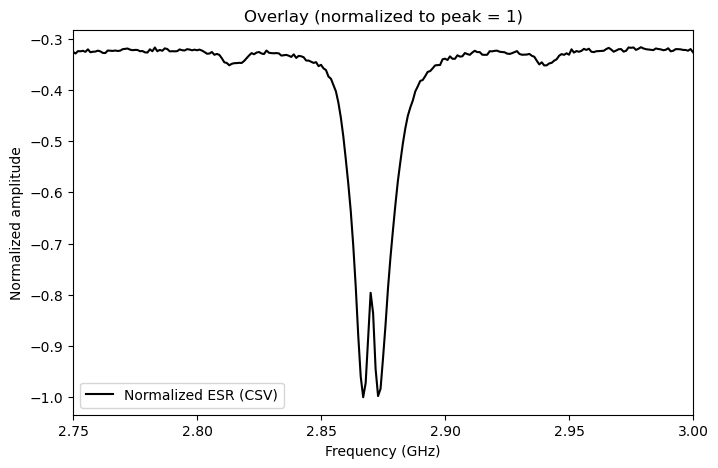

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# List three files to overlay (change names as needed)
# 'ESR_2026-1-9_011.txt' New laser new alignment
# 'ESR_2026-1-13_002.txt' Old laser new alignment
# 'ESR_2025-11-10_004.txt' Old laser old alignment
files = ['ESR_2026-1-9_011.txt', 'ESR_2026-1-13_002.txt', 'ESR_2025-11-10_004.txt']
labels = {
    'ESR_2026-1-9_011.txt': 'New laser, new alignment',
    'ESR_2026-1-13_002.txt': 'Old laser, new alignment',
    'ESR_2025-11-10_004.txt': 'Old laser, old alignment'
}
colors = ['C0', 'C1', 'C2']
plt.figure(figsize=(8,5))
for fname, color in zip(files, colors):
    rows = []
    try:
        with open(fname, 'r') as f:
            for line in f:
                line_strip = line.strip()
                if line_strip == 'END':
                    break
                if not line_strip:
                    continue
                parts = line_strip.split()
                try:
                    x = float(parts[0])
                    y = float(parts[1])
                    rows.append((x, y))
                except Exception:
                    continue
    except FileNotFoundError:
        print(f'File not found: {fname}')
        continue
    if len(rows) == 0:
        print(f'No numeric data found in {fname}')
        continue
    data = np.array(rows)
    freq = data[:, 0] / 1e9
    counts = data[:, 1]
    # Normalize each dataset so its peak (max absolute) equals 1
    max_abs = np.max(np.abs(counts)) if counts.size > 0 else 0.0
    if max_abs > 0:
        counts = counts / max_abs
    sort_idx = np.argsort(freq)
    freq = freq[sort_idx]
    counts = counts[sort_idx]
    label = labels.get(fname, fname)
    plt.plot(freq, counts, color=color, label=label, alpha=0.8)

# Add normalized ESR from CSV (use previously computed arrays if available)
try:
    if 'Frequency_norm' in globals() and 'norm_counts' in globals():
        F_norm = Frequency_norm
        N_norm = norm_counts
    elif 'Frequency_plot' in globals() and 'norm_counts_plot' in globals():
        F_norm = Frequency_plot
        N_norm = norm_counts_plot
    elif 'Frequency_mm' in globals() and 'norm_mm' in globals():
        F_norm = Frequency_mm
        N_norm = norm_mm
    else:
        # fallback: load from CSV `filename` and compute peak-normalized (max value -> 1)
        df = pd.read_csv(filename)
        data = df.iloc[:, :4].to_numpy(dtype=float)
        F_norm = data[:, 0] / 1e3
        countsN = data[:, 2] * globals().get('UNIT_SCALE', 1.0)
        max_val = np.max(countsN) if countsN.size > 0 else 1.0
        if max_val <= 0:
            alt = np.max(np.abs(countsN)) if countsN.size > 0 else 1.0
            max_val = alt if alt != 0 else 1.0
        N_norm = countsN / max_val
    plt.plot(F_norm, N_norm, color='k', lw=1.5, label='Normalized ESR (CSV)')
except Exception as e:
    print('Could not add normalized ESR overlay:', e)

plt.xlabel('Frequency (GHz)')
plt.ylabel('Normalized amplitude')
plt.title('Overlay (normalized to peak = 1)')
plt.xlim(2.75,3)
plt.legend()
plt.show()

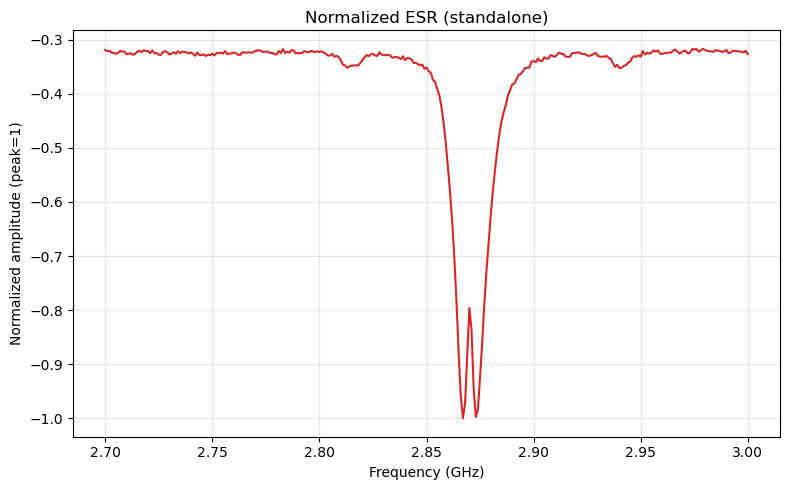

Plotted 301 points; peak before normalization: 0.00019223033951323718


In [8]:
# Standalone normalized ESR plot (peak-normalized: max -> 1)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Try to reuse previously computed normalized arrays
Frequency_n = globals().get('Frequency_norm') or globals().get('Frequency_plot') or globals().get('Frequency_mm')
norm_n = globals().get('norm_counts') or globals().get('norm_counts_plot') or globals().get('norm_mm')
counts_n = None
if Frequency_n is None or norm_n is None:
    # Load from CSV `filename` and compute peak-normalized signal
    try:
        df_n = pd.read_csv(filename)
    except Exception as e:
        raise RuntimeError(f'Cannot read {filename}: {e}')
    data_n = df_n.iloc[:, :4].to_numpy(dtype=float)
    Frequency_n = data_n[:, 0] / 1e3  # MHz -> GHz
    counts_n = data_n[:, 2] * globals().get('UNIT_SCALE', 1.0)
    # filter finite
    mask = np.isfinite(Frequency_n) & np.isfinite(counts_n)
    Frequency_n = Frequency_n[mask]
    counts_n = counts_n[mask]
    # peak normalization (highest value -> 1); fall back to abs peak if needed
    max_val = np.max(counts_n) if counts_n.size > 0 else 1.0
    if max_val <= 0:
        alt = np.max(np.abs(counts_n)) if counts_n.size > 0 else 1.0
        max_val = alt if alt != 0 else 1.0
    norm_n = counts_n / max_val
# If we reused existing normalized arrays, ensure arrays are numpy and finite
if not isinstance(Frequency_n, np.ndarray):
    Frequency_n = np.array(Frequency_n, dtype=float)
if not isinstance(norm_n, np.ndarray):
    norm_n = np.array(norm_n, dtype=float)
finite = np.isfinite(Frequency_n) & np.isfinite(norm_n)
Frequency_n = Frequency_n[finite]
norm_n = norm_n[finite]
if Frequency_n.size == 0:
    raise RuntimeError('No valid data to plot for normalized ESR')
plt.figure(figsize=(8,5))
plt.plot(Frequency_n, norm_n, '-', color='C3', lw=1.5)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Normalized amplitude (peak=1)')
plt.title('Normalized ESR (standalone)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Plotted {Frequency_n.size} points; peak before normalization: {np.max(np.abs(counts_n)) if counts_n is not None else "unknown"}')